<a href="https://colab.research.google.com/github/konishogu/DeepLearning/blob/main/EVALUACION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



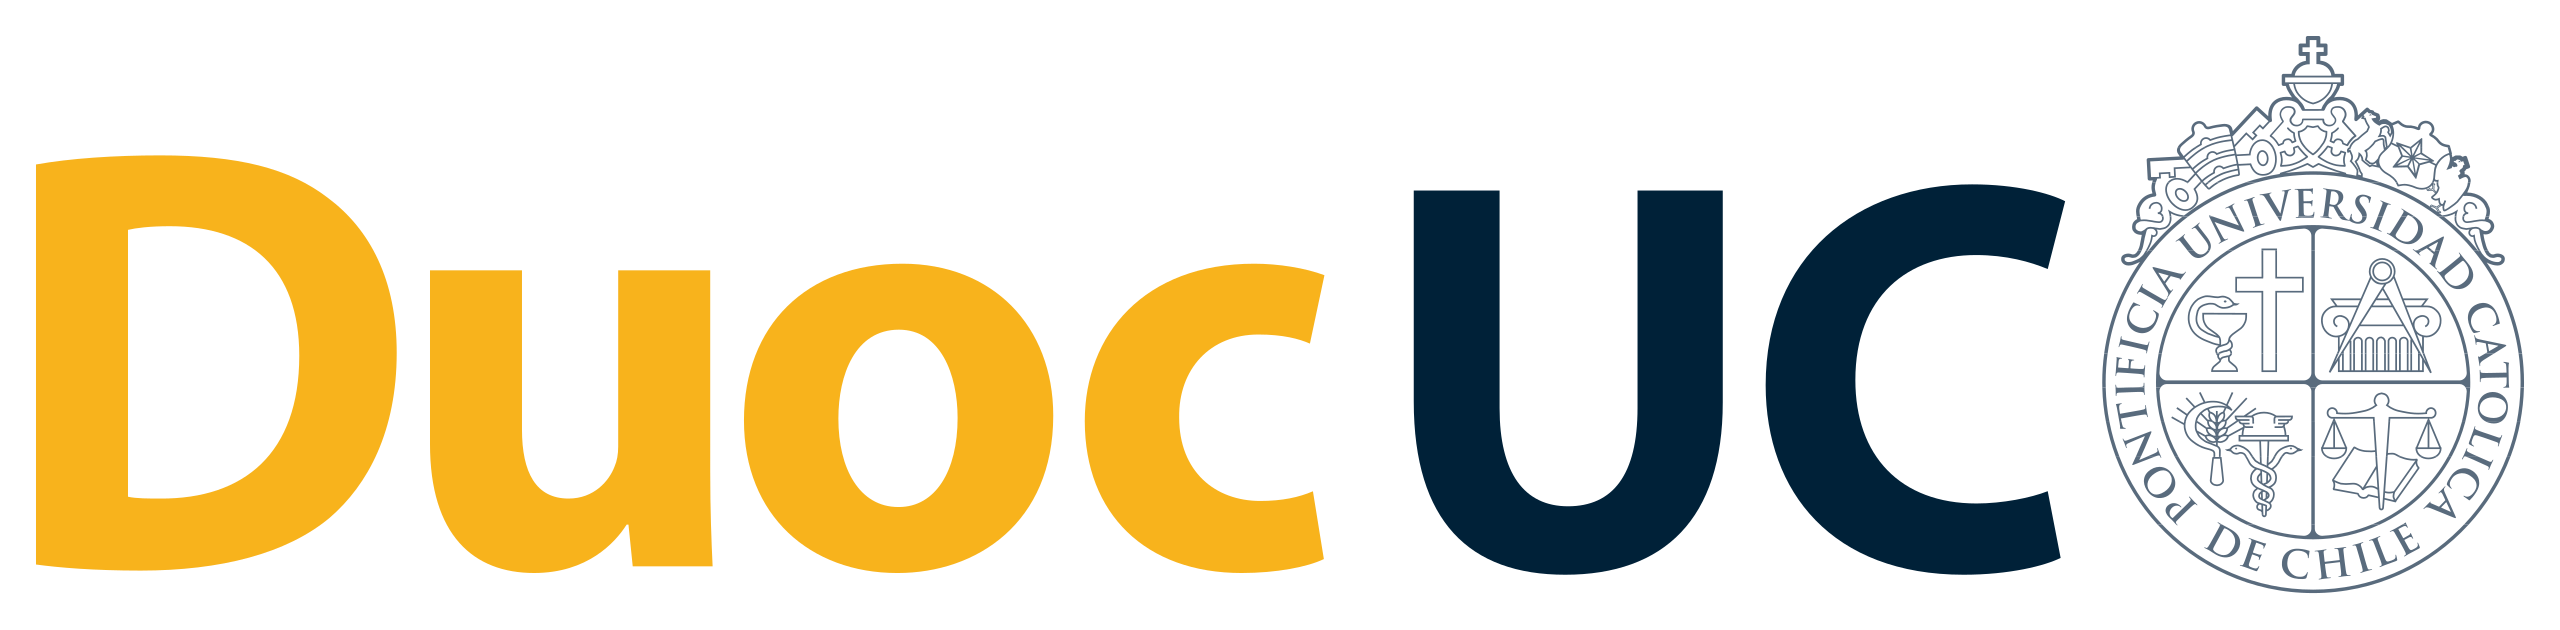



---
**Autores:**

- Matias Ignacio Wastavino Gonzalez
- Luis Rodrigo Nicolas Mendez Lehner
- Rodrigo Antonio Carcamo Rojas
- Matias Ignacio Molina Sepulveda
- Alejandra Ignacia Riquelme Velásquez

**Docente:** Marcelo Alejandro Tapia Contreras Tapia Contreras

**Asignatura:** Deep learning

**Sección:** 003D

**Institución:** Duoc UC - Sede Melipilla

**Fecha de entrega:** 24 de Abril de 2026

---

## **Introducción**
En el presente trabajo se aborda el desarrollo de un modelo de Deep Learning utilizando una red neuronal multicapa (MLP) con el objetivo de resolver un problema de clasificación de imágenes. Para ello, se emplea el dataset Fashion-MNIST, el cual contiene imágenes en escala de grises de distintas prendas de vestir, tales como camisetas, pantalones, zapatos y bolsos.

Este conjunto de datos está compuesto por imágenes de tamaño 28x28 píxeles, organizadas en 10 clases diferentes, lo que lo convierte en un problema de clasificación multiclase. Cada imagen representa una prenda específica, y el objetivo del modelo es aprender a identificar correctamente la categoría a la que pertenece cada una.

El propósito principal de este trabajo es diseñar, entrenar y evaluar un modelo basado en redes neuronales artificiales, aplicando técnicas fundamentales de Deep Learning como el preprocesamiento de datos, la selección de funciones de activación, la optimización de hiperparámetros y la evaluación mediante métricas como accuracy, precision, recall y F1-score.

Adicionalmente, se realizarán experimentos controlados para analizar el impacto de distintos parámetros del modelo, tales como la tasa de aprendizaje, el número de épocas y el tamaño del batch, con el fin de mejorar su desempeño y comprender su comportamiento durante el proceso de entrenamiento.



# **Fase 1: Preprocesamiento de datos**

## **1. Cargar los datos**

### **1.1. Importaciones necesarias**

*En esta sección se han definido las herramientas fundamentales para el desarrollo de la red neuronal artificial (MLP).*

In [ ]:
# Permite trabajar con redes neuronales
import tensorflow as tf

# Permite visualizar graficos e imágenes
import matplotlib.pyplot as plt

# Permite construir y entrenar modelos
from tensorflow import keras

# Permite manejar y manipular arreglos numéricos y matrices
import numpy as np

1. Tensorflow como la base que permite a la red neuronal aprender a partir de los datos, ya que se encarga de realizar los cáculos necesarios para ajustar los parámetros del modelo (pesos y bias) y mejorar sus predicciones con el tiempo. Sin esta librería, el entrenamiento sería mucho más complejo, ya que habría que implementar manualmente todos estos procesos.

2. Matplotlib para visualizar tanto los datos como los resultados del modelo. Gracias a esta herramienta es posible representar imágenes y gráficos de forma clara, lo que facilita entender el comportamiento del entrenamiento y detectar posibles problemas. Sin esto, el análisis se limitaría a valores numéricos, dificultando la interpretación.

3. Keras para reducir la complejidad de desarrollo, ofreciendo funciones listas para definir, entrenar y evaluar el modelo de manera simple y estructurada, permitiendo enfocar el trabajo en el diseño del modelo y el análisis de resultados, en lugar de implementar cada componente desde cero.

4. Numpy para transformar las imágenes en estructuras matemáticas que el modelo pueda entender. Esta herramienta nos permite limpiar, organizar y normalizar los píxeles del dataset de forma rápida. Sin este elemento, no podríamos entregarle los datos a la red neuronal en el formato adecuado para que aprenda.

### **1.2. Versionado**

Al ejecutar el código se obtiene la versión de TensorFlow instalada en el entorno, permitiendo asegurar que las funciones a utilizar sean compatibles y funcionen correctamente.

In [ ]:
# Verificar versión de TensorFlow
print(f"{tf.__version__}")

2.19.0


### **1.3. Dataset**

En este apartado, el código permite acceder al dataset Fashion-MNIST desde Keras y cargarlo en el entorno de trabajo. Este conjunto de datos se encuentra previamente dividido en dos partes: un conjunto de entrenamiento, utilizado para que la red neuronal aprenda patrones, y un conjunto de prueba, que se emplea para evaluar el rendimiento del modelo con datos que no ha visto anteriormente.

In [ ]:
# Acceder al dataset
fashion_mnist = keras.datasets.fashion_mnist

# Separar en datos de entrenamiento y prueba
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Verificar la forma de los datos cargados
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X_train_full.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y_train_full.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_test.shape}")
print(f"------------------------------------------------")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
------------------------------------------------
Imágenes de entrenamiento: (60000, 28, 28)
------------------------------------------------
Etiquetas de entrenamiento: (60000,)
------------------------------------------------
Imágenes de prueba: (10000, 28, 28)
------------------------------------------------


**CONCLUSIONES:**

- Mediante el uso de .shape, se imprime la forma de cada conjunto de datos. Esto permite verificar que la carga se realizó correctamente, conocer la cantidad de imágenes disponibles y entender cómo están organizadas.

- En total, se cargan 70.000 imágenes, de las cuales 60.000 corresponden al entrenamiento y 10.000 a la prueba. Cada imagen está representada como una matriz de 28 x 28 píxeles y se almacena en las variables "x", mientras que sus respectivas etiquetas, es decir, la categoría de la prenda se guardan en las variables "y".

- El nombre X_train_full se utiliza para indicar que este es el conjunto de entrenamiento completo, el cual posteriormente será dividido para generar un subconjunto de validación en la siguiente fase.

### **1.4. Lista de clases**

In [ ]:
# Definir los nombres de las categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**JUSTIFICACIÓN DE DECISIÓN:**

- Al cargar el dataset Fashion-MNIST, las etiquetas y_train_full no están representadas como nombres de prendas (ej: “zapato” o “camisa”), sino como valores numéricos enteros entre 0 y 9. Para el modelo, estos números son suficientes, ya que trabaja con estas representaciones, sin embargo, para ser interpretados no entregan un significado claro por sí solos. Por esta razón, se define la lista “class_names”, que actúa como un diccionario entre cada valor numérico y su categoría correspondiente. Cada posición de la lista representa exactamente la etiqueta asignada por los creadores del dataset, tal como se especifica en la documentación oficial.

- Esta decisión permite dar contexto a los datos y facilitar su interpretación. Por ejemplo, al visualizar una imagen, se puede mostrar su etiqueta en texto y verificar si el modelo está clasificando correctamente o si confunde clases, como un “abrigo” (coat) con un “vestido” (dress). Sin esta correspondencia, solo se observarían errores entre números, dificultando el análisis.

## **2. Exploración del set de datos**

### **2.1. Distribución de clases**

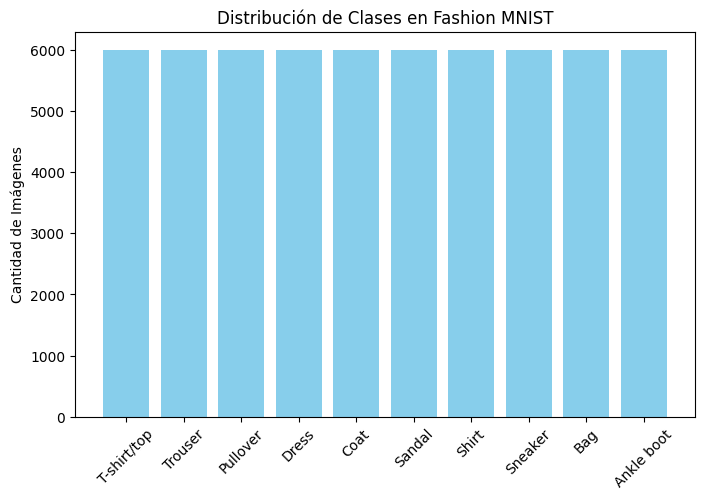

In [ ]:
# 1. Contar cuántas imágenes hay por cada categoría
unique, counts = np.unique(y_train_full, return_counts=True)

# 2. Tamaño del gráfico
plt.figure(figsize=(8, 5))

# 3. Diseño de barra usando el nombre de la prenda y su total
plt.bar(class_names, counts, color='skyblue')

# 4. Rotar etiquetas y añadir títulos
plt.xticks(rotation=45)
plt.title("Distribución de Clases en Fashion MNIST")
plt.ylabel("Cantidad de Imágenes")

# 5. Mostrar resultado
plt.show()

*JUSTIFICACIÓN Y ANÁLISIS DE CODIGO:*

- Se está utilizando np.unique con el parámetro return_counts=True para extraer la frecuencia exacta de cada una de las 10 categorías en el dataset, luego hacemos uso de la librería matplotlib para generar un gráfico de barras para poder tener otra forma de visualizar las categorías del dataset con la cantidad de datos que contienen, también se hace uso de este modo de visualización para detectar posibles sesgos en los datos de entrenamiento ya que si una red neuronal se entrena con un dataset donde una clase tiene muchas más muestras que otra el modelo va a desarrollar un sesgo hacia la clase con mayor datos.

*JUSTIFICACIÓN Y ANÁLISIS DEL GRAFICO Y RESULTADOS:*

- Se visualiza que el gráfico nos dice que los datos tienen una distribución uniforme ya que si se observa con más detalle cada una de las variables que están presentes en el dataset alcanzan exactamente el valor de 6.000 datos, sumando todos los datos de las 10 variables nos da el total de 60.000 datos los cuales son los datos que dejamos de entrenamiento, así que por eso podemos decir que esta distribución es uniforme, en resumen tenemos un dataset perfectamente balanceado.

### **2.2. Integridad de los datos**

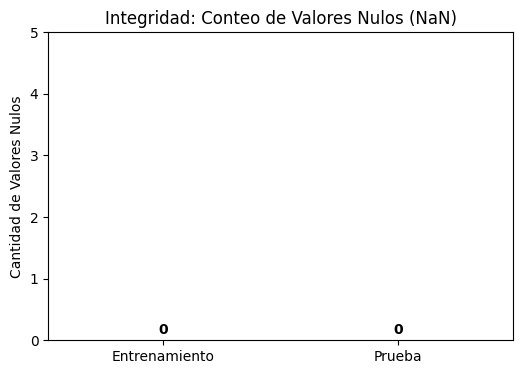

In [ ]:
def plot_missing_values(x_train, x_test):
    # Calcular cuántas imágenes tienen un valor nulo
    nulos_train = np.isnan(x_train).sum()
    nulos_test = np.isnan(x_test).sum()

    sets = ['Entrenamiento', 'Prueba']
    valores = [nulos_train, nulos_test]

    # Crear gráfico de barras
    plt.figure(figsize=(6, 4))
    bars = plt.bar(sets, valores, color=['#e74c3c', '#3498db'])

    # Añadir número sobre la barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval),
                 ha='center', fontweight='bold')

    plt.title('Integridad: Conteo de Valores Nulos (NaN)')
    plt.ylabel('Cantidad de Valores Nulos')
    plt.ylim(0, max(valores) + 2 if max(valores) > 0 else 5)
    plt.show()

# Ejecutar validación
plot_missing_values(X_train_full, X_test)

*CODIGO*

 - El código que se desarrolló realiza una inspección profunda de las variables “X_train_full” y “X_test”  utilizando función de np.isnan() para identificar posiciones de memoria que no contengan un número válido y luego los suma, luego realiza un gráfico para poder visualizar los datos para poder facilitar la interpretación de estos, por que en deep learning aprenden mediante el ajuste de pesos usando gradientes, teniendo esto en cuenta, si un valor “NAN” entra en la red, cualquier operación matemática posterior resultará en “NAN” esto se termina propagando por toda la red haciendo que la pérdida (loss) se vuelva “NAN” dejando un modelo inservible.

*GRÁFICO*

- Se observa que en el gráfico de barras tanto como la barra de datos de entrenamiento como los de prueba contienen un total de 0 datos con valor “NAN” lo que nos dice que la integridad del dataset es perfecta, no existen huecos de información en las imágenes ni en las etiquetas, al tener esta información podemos tener justificación sólida del por qué podemos omitir el paso de limpieza como por ejemplo la imputación de los datos o eliminación de las filas con datos corruptos (“NAN”) así que al tener esta información podríamos pasar directamente a la normalización y al diseño de la arquitectura de la red.

## **3. Tratamiento**

### **3.1. Visualización de muestra con mapa de calor**

Antes de aplicar cualquier técnica de preprocesamiento, es importante inspeccionar los datos en su estado original. En esta sección se visualiza una imagen del conjunto de entrenamiento como ejemplo, lo que permite entender cómo están representados los datos internamente. A través de esta visualización, se puede entender como cada imagen se relaciona a una matriz de valores y de conocer el rango de intensidad de sus píxeles.

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------


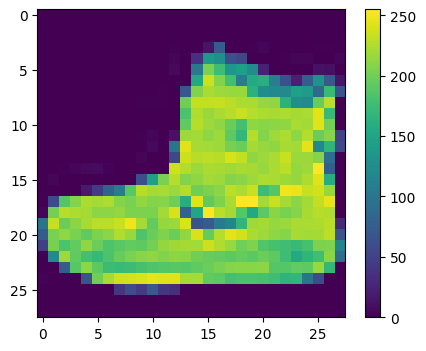

In [ ]:
# Configurar la impresión para ver la matriz completa
np.set_printoptions(linewidth=200)

print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")

# Definir tamaño del gráfico
plt.figure(figsize=(5,4))
# Mostrar la imagen
plt.imshow(X_train_full[0])
# Agregar una leyenda lateral
plt.colorbar()
# Mostrar resultado
plt.show()

**OBSERVACIÓN Y ANÁLISIS:**

- La salida es una representación numérica del objeto, ya que una imagen digital no es más que una cuadrícula de pequeños elementos llamados píxeles. Los colores que se observan en la visualización son solo una ayuda para facilitar la interpretación, ya que la máquina no "ve" colores, sino únicamente números. En este contexto, los tonos oscuros, como el púrpura, representan valores cercanos a 0, que corresponden al fondo de la imagen. Por otro lado, los tonos más claros, como el amarillo, indican valores altos cercanos a 255, los cuales forman la silueta del objeto.

- Gracias a esta variación de intensidades es posible distinguir bordes, formas y detalles de la imagen, como en este caso la bota. Esto permite entender de mejor manera cómo el modelo interpreta los datos: no como objetos visuales, sino como patrones numéricos que representan su estructura.

### **3.2. Representación matricial**

In [ ]:
# Mostrar la "verdad" de la computadora (los números)
print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")
print("Matriz de píxeles de la imagen:")
print(f"-------------------------------------------------------")
print(X_train_full[0])

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------
Matriz de píxeles de la imagen:
-------------------------------------------------------
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 

**OBSERVACIONES:**

- La imagen está representada como una matriz de números, similar a un mapa de coordenadas. Cada valor corresponde a la intensidad de un píxel, lo que permite ver con mayor claridad cómo la computadora interpreta una imagen. En este caso, los bordes de la matriz están compuestos principalmente por valores cercanos a 0, indicando la ausencia de información (fondo negro), mientras que en el centro se concentran valores más altos que forman la silueta de la bota.

- Esta distribución de valores permite identificar tanto la forma del objeto como la estructura de la imagen, que está compuesta por 28 filas y 28 columnas. A diferencia de la visualización anterior, esta representación muestra exactamente cómo la red neuronal recibe y procesa los datos.
---

**CONCLUSIÓN:** Los valores al ir de 0 a 255 dificultan el aprendizaje del modelo, ya que valores grandes pueden generar inestabilidad y hacer que el entrenamiento sea más lento o menos preciso. Por esta razón, sería necesario aplicar un escalado de los datos a un rango entre 0 y 1. Esto permite que la red neuronal entrene de forma más estable, eficiente y con mejores resultados.


### **3.3. Normalización de los datos**

En este paso, el código proporcionado realiza una operación simple pero muy importante, divide el valor de cada píxel por 255. Antes de esto, los píxeles estaban representados por números enteros entre 0 (negro) y 255 (blanco). Al hacer esta división, todos los valores pasan a estar en un rango entre 0.0 y 1.0

In [ ]:
# Normalizar las imágenes de entrenamiento
X_train_full = X_train_full / 255.0

# Aplicar el mismo escalado al set de prueba
X_test = X_test / 255.0

**JUSTIFICACIÓN:**

- Este cambio facilita el trabajo de la red, ya que es más eficiente procesando números pequeños que valores grandes. Además, muchas funciones de activación, como ReLU o sigmoide, funcionan mejor cuando los datos están en rangos cercanos a 0.

- También ayuda durante el entrenamiento: la red aprende ajustando sus parámetros mediante pequeños cambios (gradientes). Si los valores son muy grandes, estos cambios pueden ser demasiados bruscos y hacer que el modelo no aprenda bien. Por tanto, al poner todos los datos en el mismo rango, está no pierde tiempo lidiando con diferencias de escala y puede enfocarse directamente en aprender las formas y patrones de las imágenes.

### **3.4. Verificar muestras normalizadas**

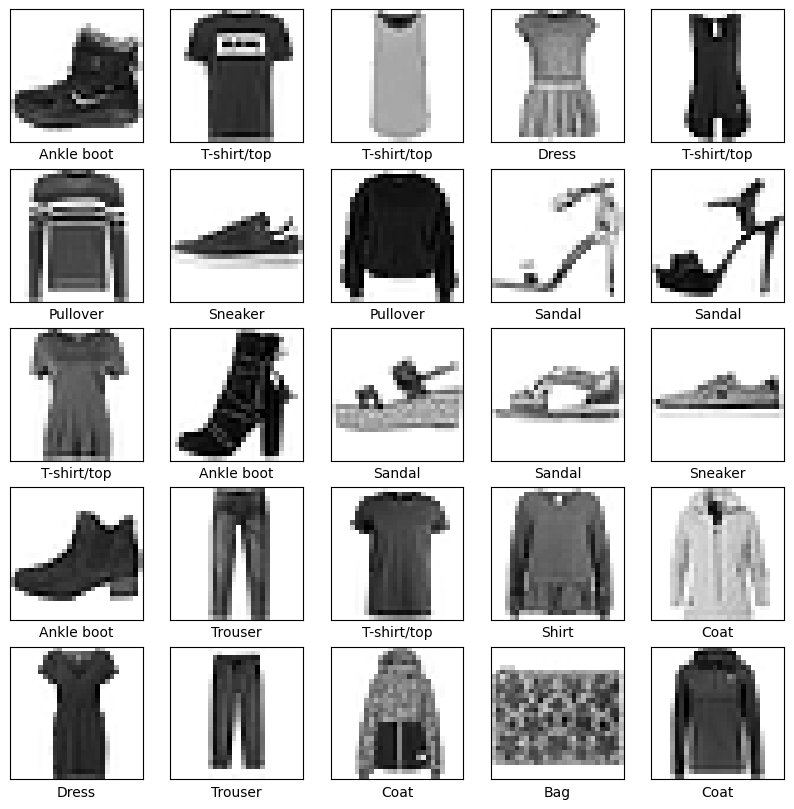

In [ ]:
# Definir el tamaño del lienzo
plt.figure(figsize=(10,10))

# Iterar sobre las primeras 25 imágenes
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Mostrar la imagen en escala de grises
    plt.imshow(X_train_full[i], cmap=plt.cm.binary)
    # Colocar el nombre de la categoría
    plt.xlabel(class_names[y_train_full[i]])

# Mostrar resultado
plt.show()

*Análisis y justificación:*

Una vez realizado el escalado lo que se está haciendo en el código es generar una matriz de visualización de los datos de entrenamiento, primero hacemos uso de plt.figure para definir un área de dibujo para que las imágenes no se vean amontonadas, después se crea un bucle (for i in range(25)) que selecciona las primeras 25 imágenes del dataset para crear una muestra representativa, paso seguido organizamos estas imágenes en cuadrículas de 5x5 luego hacemos una limpieza estética para evitar distracciones visuales para terminar mostrando las imágenes en escala de grises y colocando el nombre de la categoría debajo de cada imagen correspondiente. Se está haciendo uso de este código y decisión para poder verificar que el mapeo de “class_name” es correcto ya que si bajo la imagen de un zapato y el código de salida me diera un “T-shirt” se sabría que hay un error en la carga de etiquetas o en el orden de la lista de “class_name”, teniendo esto en cuenta si se entrena el modelo con etiquetas erróneas resulta en un modelo incapaz de generalizar, osea inservible. Por otro lado, también podemos permitirnos entender bien a que se enfrenta la red neuronal ya que al tener una visualización clara de algunas imágenes podemos darnos cuenta que hay ciertas similitudes en algunas de ellas, esto también justifica el por que el modelo podría tener dificultades para aprender. Finalmente, podemos confirmar visualmente que la resolución de 28x28 es suficiente para distinguir las imágenes y la categoría a la cual pertenecen, todos estos detalles se pudieron detectar utilizando este código y estas son las razones del por que se uso este y la toma de desiciones.


# **Fase 2: Configuración** (Setup inicial de epocas, learning rate y batch size diseño de la arquitectura base.)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


En nuestro primer código estamos transformando cada imagen de 28x28 pixeles en un vector lineal de 784 valores (28x28). Esto lo hacemos de manera obligatoria porque más abajo estaremos usando capas “Dense”, la cual quiere decir que es una capa densa o conectada, en palabras simples, cada una de las 128 neuronas, estará conectada con todos los 784 píxeles, cabe destacar que Dense solo aceptan datos unidimensionales (vector lineal).

Luego tenemos una capa oculta con 128 neuronas, las cuales consideramos es un tamaño equilibrado para extraer patrones de prendas sin tener un exceso de costo computacional, haya overfitting o aprenda poco por falta de neuronas. Seguidamente hacemos la activación con la función ReLU, la cual nos ayuda a poder introducir no linealidad, esto nos sirve para poder aprender formas complejas, es decir, formas que no son tan simples como una línea vertical, horizontal y ya, sino por ejemplo la forma de una polera, la cual tiene muchas curvas, líneas, etc. Esto ayudará a que la red se entrene más rápido. Cabe destacar que esto lo hace tomando los resultados de las sumas y multiplicaciones que se hicieron anteriormente en la red, en caso de que el resultado sea negativo, lo dejará en 0 y si es positivo, lo dejará tal cual.

Posteriormente tenemos la capa de salida, en donde configuramos 10 neuronas ya que el dataset tiene 10 categorías de ropa y es obligatorio usar la misma cantidad de neuronas como categorías tenga nuestro set de datos. La función Softmax es muy importante porque nos transforma las salidas numéricas en probabilidades, esto es para saber qué certeza tiene la red con cada categoría, es decir, que tan bien predice que es una polera, una zapatilla, un pantalón, etc. Softmax toma los resultados crudos de las 10 neuronas y los convierte en porcentajes que suman 100%. Dice algo así como: “Estoy 80% seguro que es una chaqueta, 10% de que es una polera y otro 10% de que es una camisa”. En pocas palabras la capa de salida, nos ayuda a recolectar información procesada por la capa anterior y entregar la predicción final.


In [ ]:
epochs = 10
batch_size = 32
learning_rate = 0.001

Definimos las epocas, q seria la cantidad de veces que el modelo vera los datos, utilizamos batch_size de 32 para definir cuantas imagenes se precesaran

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Se permite visualizar la estrucutra completa del modelo. Esta herramienta muestra las capas que componen la red neuronal, los parametros entrenables y la forma de datos en cada etapa , esto es fundamental para verificar que el modelo ha sido countruido correctamente antes de iniciar el precoeso de entrenamiento.

## **Fase 3: Funciones core** (Implementacion y justificacion de las funciones de activacion, error y la salida.)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Se configura el modelo para su entrenamiento mediante la funcion compile(), Utilizamos el optimizador ADAM con una tasa de aprendizajer de 0.001 el cual permite ajustar parabmetros del modelo, tambien se defiine la funcion de perdida (sparse_categorical_crossentropy) bueno para problemas de clasificacion multiclase cuando las etiquetas esten representadas como valores numericos, se utliza accuracy como metrica de evaluacion para medir el porcetnaje de aciertos del modelo durante el entramiento

In [ ]:
history = model.fit(
    X_train_full, y_train_full,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8185 - loss: 0.5210 - val_accuracy: 0.8514 - val_loss: 0.4212
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8602 - loss: 0.3900 - val_accuracy: 0.8658 - val_loss: 0.3893
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8728 - loss: 0.3461 - val_accuracy: 0.8737 - val_loss: 0.3552
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8819 - loss: 0.3203 - val_accuracy: 0.8779 - val_loss: 0.3373
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8884 - loss: 0.2999 - val_accuracy: 0.8773 - val_loss: 0.3335
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8940 - loss: 0.2861 - val_accuracy: 0.8787 - val_loss: 0.3330
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8996 - loss: 0.2723 - val_accuracy: 0.8831 - val_loss: 0.3305
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9027 - loss: 0.2605 -

aqui iniciamos el entrenamiento con datos como x_train_full, y_train_full, tambien la cantidad de epocas defenidas anteriormente y su batch, luego separa el 0.2 (20%) de los datos para validar, conesto evaluamos mientras entrenamos.

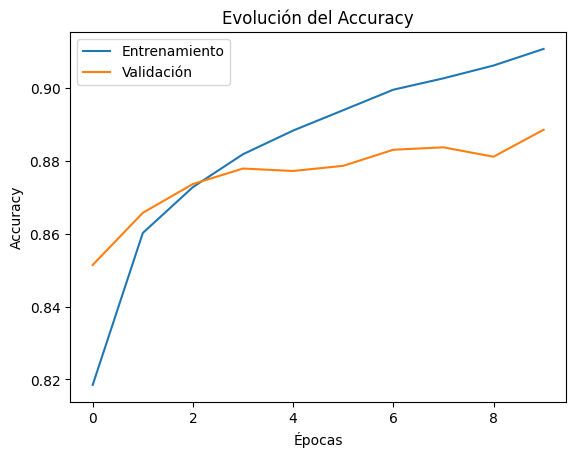

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Evolución del Accuracy')
plt.show()

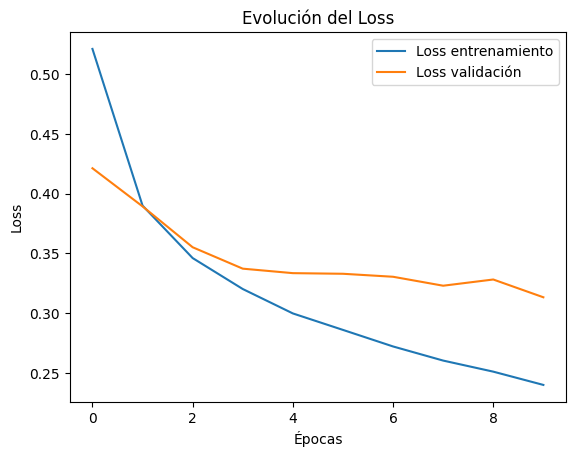

In [ ]:
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Evolución del Loss')
plt.show()

## **Fase 4: Optimización** (Estabilizacion del modelo y mitigacion del overfiting mediante dropout y regulizacion.)

In [ ]:
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
epochs = 18
batch_size = 128

In [ ]:
history = model.fit(
    X_train_full, y_train_full,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7628 - loss: 0.6860 - val_accuracy: 0.8320 - val_loss: 0.4586
Epoch 2/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8319 - loss: 0.4769 - val_accuracy: 0.8528 - val_loss: 0.4056
Epoch 3/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8463 - loss: 0.4311 - val_accuracy: 0.8612 - val_loss: 0.3846
Epoch 4/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8578 - loss: 0.4026 - val_accuracy: 0.8684 - val_loss: 0.3629
Epoch 5/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8621 - loss: 0.3874 - val_accuracy: 0.8666 - val_loss: 0.3717
Epoch 6/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8653 - loss: 0.3736 - val_accuracy: 0.8713 - val_loss: 0.3552
Epoch 7/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8675 - loss: 0.3648 - val_accuracy: 0.8791 - val_loss: 0.3384
Epoch 8/18
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8726 - loss: 0.3534 - val_accuracy: 0.

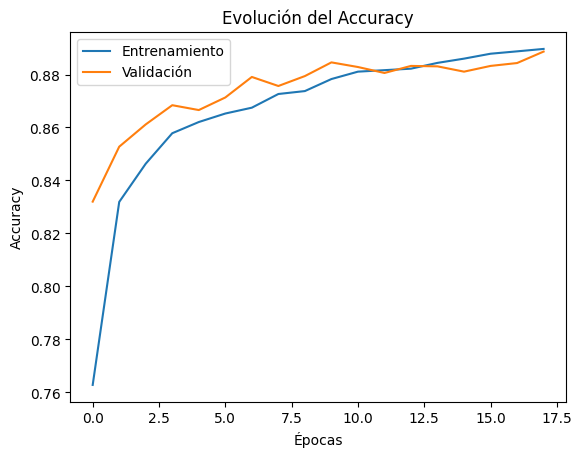

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Evolución del Accuracy')
plt.show()

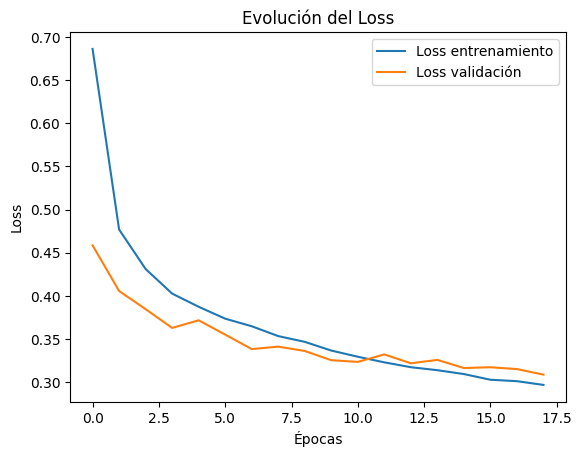

In [ ]:
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Evolución del Loss')
plt.show()

## **Fase 5: Evaluación** (Calculo matematico e interpretacion de Accuracy, precision, recall y f1-score)

#Evaluacion del modelo, ademas de metris de confusión

en esta parte es donde se evañua la presición del modelo y su perdida, esto siguiendo los siguientes pasos

primero obtenesmos la presición y perdida al termino de la ultima epoca

en y_prod se guarda la probabilidad  que le da modelo a cada una de las 10000 imagenes en base a las 10 clases dispoibles. esto atraves del metodo predict que tiene la red este metodo recorre los 784 pixeles que tiene cada imagen y en un array almacena la probabiidad que tiene esa imagen de ser cada una de las clases

Y_pred_clases en esta variable se almacena por cada imagen la probabilidad mas alta obtenida por cada clase, esto se logra con numpy np.argmax y su metodo argmax, el cual recibe los valores(en el paso anterior los resultados quedarom en un array) y con el parametro axis = 1 le decimos que busque por fila, en caso de ser 0 buscaria por cada columna

el siguiente paso es imprimir las metricas mas importantes de la red, para esto se uso  sklearn.metrics , esta es una libreria univerzal para obtener este tipo de metricas, en concreto se uso 2 metodos classification_report, confusion_matrix

con classification_report se obtiene precision    recall  f1-score   support, para esto es necesario pasarle entre los parentesis, los valores reales de testeo, en este caso puede ser y_test, o y_true (ya que ambos contienen las imagenes), el segundo parametro son las probabilidad que le dio la red a cada imagen de ser una de las 10 clases en este caso la variable a pasar es Y_pred_clases, y el tercer y ultimo parametro son las clases almacenadas en class_names

el siguiente paso es obtener los valores de confusion esto con el metodo confusion_matrix el cual recibe como paramtro y_test o y_true(imagenes de teste0) y el segundo parametro es la probabilidad almacenada en Y_pred_clases

el ultimo paso es visualizar la matriz esto a traves de matplotlib

Accuracy: 88.14%
Pérdida: 0.3338
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.81      0.79      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.81      0.79      0.80      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.69      0.67      0.68      1000
     Sneaker       0.95      0.94      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.94      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



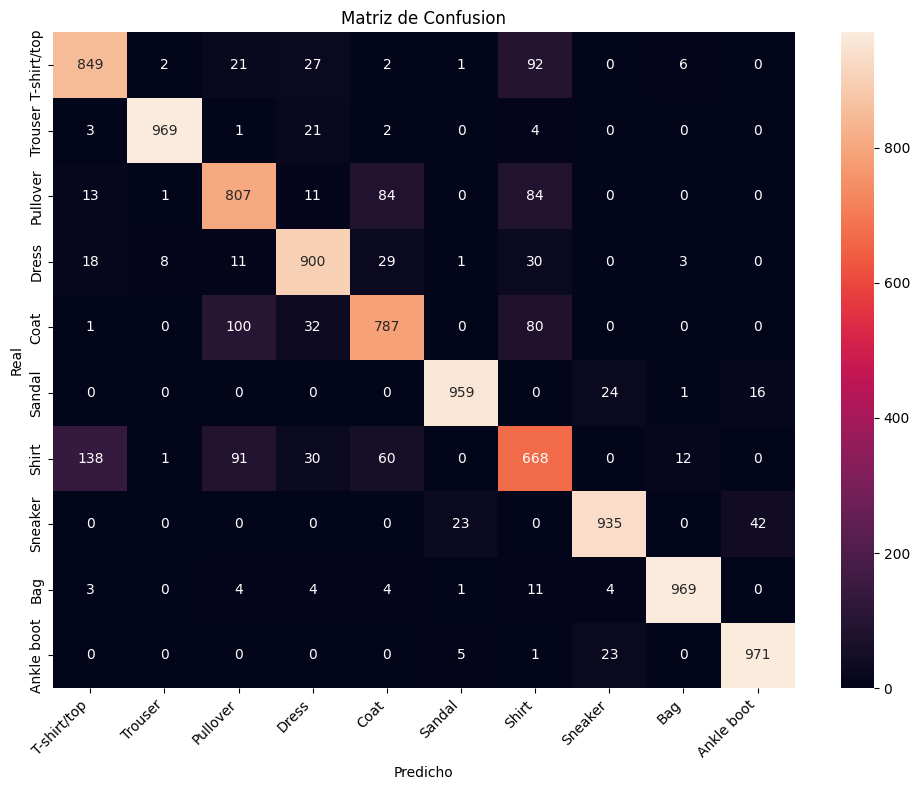

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# evaluamos el modelo
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Pérdida: {loss:.4f}")

# metricas completas por clase
Y_pred = model.predict(X_test, verbose=0)
Y_pred_clases = np.argmax(Y_pred, axis=1)
Y_true = y_test

print(classification_report(Y_true, Y_pred_clases, target_names=class_names))

  #################
  ###ARREGLAR######
  #################

# matriz de confusion
cm = confusion_matrix(Y_true, Y_pred_clases)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusion')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Conclusión**